# 09 — Tree-Based Methods
**Goal:** Master decision trees, Random Forests, and Boosting — the workhorse
of applied ML on tabular data. Source: ISLR Ch8, Hastie-Tibshirani-Friedman
Ch9-10, Géron Ch6-7.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification
np.random.seed(9)

## 1. Why trees are different

Linear models (notebooks 05-08) split the feature space with *hyperplanes*.
Trees split it with *axis-aligned cuts*. The two are different
approximators of the same underlying function:

| Aspect | Linear | Tree |
|---|---|---|
| Functional form | smooth | step function |
| Interaction modeling | manual (x₁·x₂) | automatic (every split) |
| Scaling | needed | not needed |
| Outlier sensitivity | high | low (in x), high (in y for regression) |
| Interpretability | coefficients | can draw the tree |
| Extrapolation | yes | no (flat beyond training x) |

In 2024, **gradient-boosted trees (XGBoost, LightGBM, CatBoost) still win
most Kaggle competitions on tabular data.** That is the entire reason this
notebook exists.

## 2. The CART algorithm — Classification and Regression Trees

**Top-down, greedy.** Start at the root. For every possible split (feature j,
threshold t) of the current node, compute the reduction in some impurity
measure. Take the split that reduces it the most. Recurse on the children
until a stopping rule triggers. Then **prune**.

**Regression impurity:** RSS in the child nodes.

**Classification impurity (three interchangeable ones):**

- Misclassification: 1 - max pₖ
- Gini: 1 - Σ pₖ²
- Entropy: -Σ pₖ log pₖ

Gini and entropy are smooth and give similar trees. Misclassification is
less informative for growing.

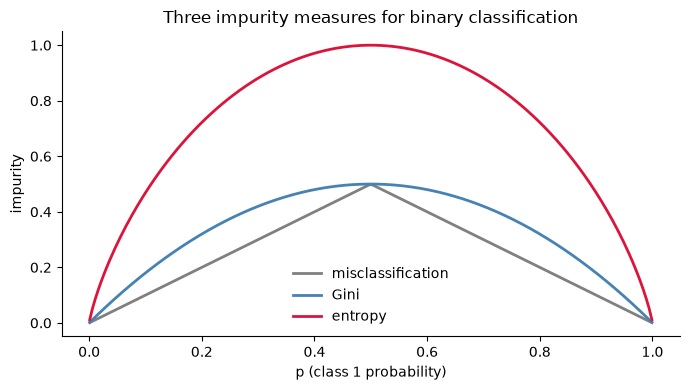

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
p = np.linspace(0.001, 0.999, 200)
ax.plot(p, 1 - np.maximum(p, 1-p), color='gray',   lw=2, label='misclassification')
ax.plot(p, 1 - (p**2 + (1-p)**2),   color='steelblue', lw=2, label='Gini')
ax.plot(p, -(p*np.log2(p) + (1-p)*np.log2(1-p)), color='crimson', lw=2, label='entropy')
ax.set_xlabel('p (class 1 probability)'); ax.set_ylabel('impurity')
ax.set_title('Three impurity measures for binary classification')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Growing and pruning

**Grow** until every leaf is pure (or has min_samples_leaf samples). This
tree will overfit.

**Prune** using *cost-complexity*:

    Cα(T) = Σ_{leaves} N_m Q_m + α |T|

where Q_m is the impurity in leaf m and α trades off tree size against
fit. As α increases, the optimal subtree shrinks. The right α is chosen by
CV — this is the `ccp_alpha` parameter in sklearn.

**Practical:** sklearn's default uses *pre-pruning* (max_depth,
min_samples_leaf, max_leaf_nodes) which is faster and almost as good.

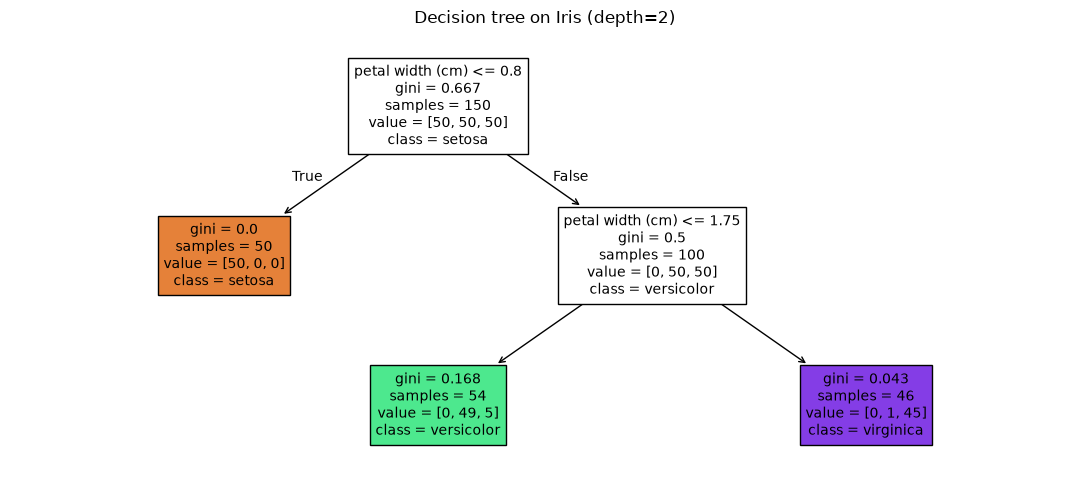

In [3]:
from sklearn.datasets import load_iris
X, y = load_iris().data, load_iris().target
tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, y)
fig, ax = plt.subplots(figsize=(11, 5))
plot_tree(tree, feature_names=load_iris().feature_names,
          class_names=load_iris().target_names, filled=True, ax=ax, fontsize=10)
ax.set_title('Decision tree on Iris (depth=2)')
plt.tight_layout(); plt.show()

## 4. Why a single tree is not enough

CART has **low bias** (it can fit any function given enough depth) but
**high variance** — small changes in the data produce very different trees.
**The fix is to average many trees** — bagging, Random Forest, boosting.

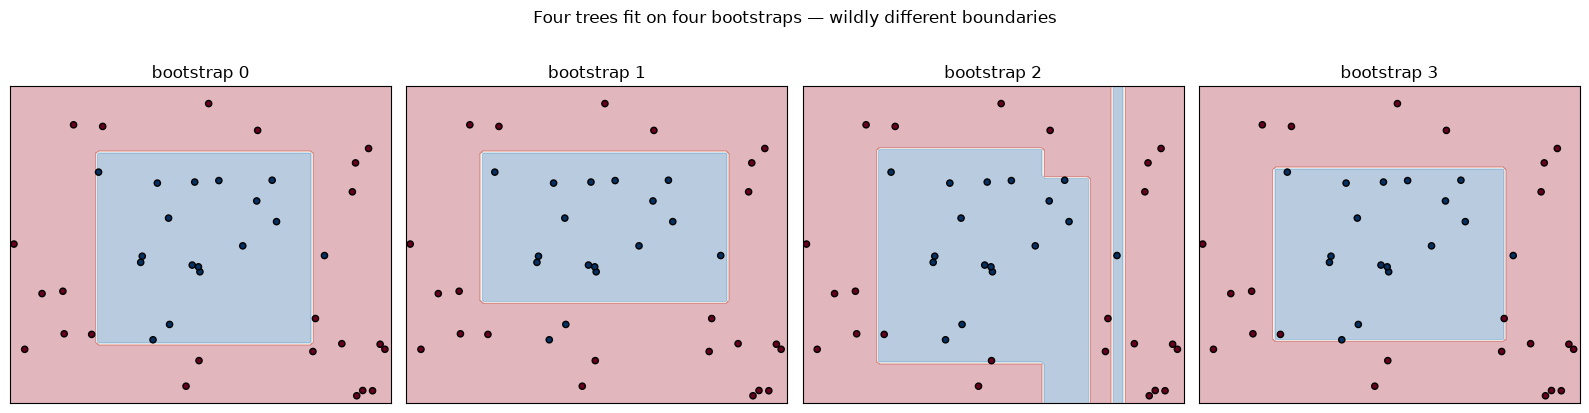

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
np.random.seed(9)
X = np.random.uniform(-1, 1, (40, 2))
y = (X[:, 0]**2 + X[:, 1]**2 > 0.5).astype(int)
for ax, seed in zip(axes, range(4)):
    idx = np.random.RandomState(seed).choice(len(X), len(X), replace=True)
    t = DecisionTreeClassifier(max_depth=None).fit(X[idx], y[idx])
    xs = np.linspace(-1, 1, 100); xx, yy = np.meshgrid(xs, xs)
    zz = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='RdBu_r')
    ax.scatter(*X.T, c=y, cmap='RdBu_r', edgecolor='k', s=20)
    ax.set_title(f'bootstrap {seed}')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Four trees fit on four bootstraps — wildly different boundaries', y=1.02)
plt.tight_layout(); plt.show()

## 5. Bagging — bootstrap aggregation

Train B trees, each on a bootstrap sample of the data. Average their
predictions.

    f̂_bag(x) = (1/B) Σ_b f̂_b(x)        (regression)
    f̂_bag(x) = mode({f̂_b(x)})           (classification)

The variance of the average of B independent draws with variance σ² is σ²/B.
Trees are not independent (trained on overlapping data) but bagging still
reduces variance substantially. **Out-of-bag (OOB) error** — for each
tree, evaluate on the ~37% of data not in its bootstrap — is a free CV
estimate.

In [5]:
from sklearn.ensemble import BaggingClassifier
X, y = make_classification(n_samples=500, n_features=10, random_state=0)
single = cross_val_score(DecisionTreeClassifier(), X, y, cv=5).mean()
bag    = cross_val_score(BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=0), X, y, cv=5).mean()
print(f'single tree   : {single:.3f}')
print(f'bagged (200)  : {bag:.3f}')

single tree   : 0.854
bagged (200)  : 0.888


## 6. Random Forest — bagging + random subspaces

The variance reduction of bagging is limited because the trees are
correlated (they pick the same dominant splits). Breiman's fix: at each
split, only consider a random subset of features. Typical choice:
√d for classification, d/3 for regression.

This *de-correlates* the trees and reduces variance further. Combined with
bagging, it is Random Forest (Breiman 2001).

In [6]:
rf = RandomForestClassifier(n_estimators=500, max_features='sqrt', oob_score=True, random_state=0, n_jobs=-1).fit(X, y)
print(f'RF CV not needed; OOB accuracy = {rf.oob_score_:.3f}')

RF CV not needed; OOB accuracy = 0.894


## 7. Boosting — the second paradigm

Bagging trains trees **in parallel** on bootstraps. Boosting trains them
**sequentially**, each one focusing on the mistakes of the previous.

**AdaBoost (Freund & Schapire 1997):**
1. Initialize weights wᵢ = 1/n.
2. Fit classifier f_m to weighted data.
3. Compute weighted error e_m.
4. Set α_m = log((1 - e_m) / e_m).
5. Reweight: wᵢ ← wᵢ · exp(α_m · 𝟙[yᵢ ≠ f_m(xᵢ)]).
6. Final: F(x) = sign(Σ α_m f_m(x)).

In [7]:
from sklearn.ensemble import AdaBoostClassifier
m = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=0).fit(X, y)
print(f'AdaBoost test acc: {m.score(X, y):.3f}')

AdaBoost test acc: 0.852


## 8. Gradient Boosting — the modern default

Freidman (2001) rephrased boosting as **gradient descent in function space**.
Each new tree is fit to the *negative gradient* of the loss with respect
to the current ensemble's predictions. For squared loss the negative
gradient is the **residual** — the new tree literally fits what the
ensemble got wrong.

For log loss (classification) the negative gradient is the residual in the
log-odds space. The trees are *shallow* (depth 3-6) and added with a
**shrinkage** (learning rate) factor to prevent overfit.

```
F_0 = constant
for m = 1 .. M:
    r_m = -∂L/∂F (residuals)
    h_m = fit a shallow tree to r_m
    F_m = F_{m-1} + η · h_m
```

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
m = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=0).fit(X, y)
print(f'GBM train acc: {m.score(X, y):.3f}')

GBM train acc: 0.984


## 9. Variable importance

Trees give two notions of variable importance for free:

1. **Mean decrease in impurity (MDI)** — total reduction of Gini or entropy
   attributed to splits on feature j, averaged over all trees.
2. **Permutation importance** — randomly shuffle column j and measure how
   much the model's performance drops. More reliable for correlated
   features.

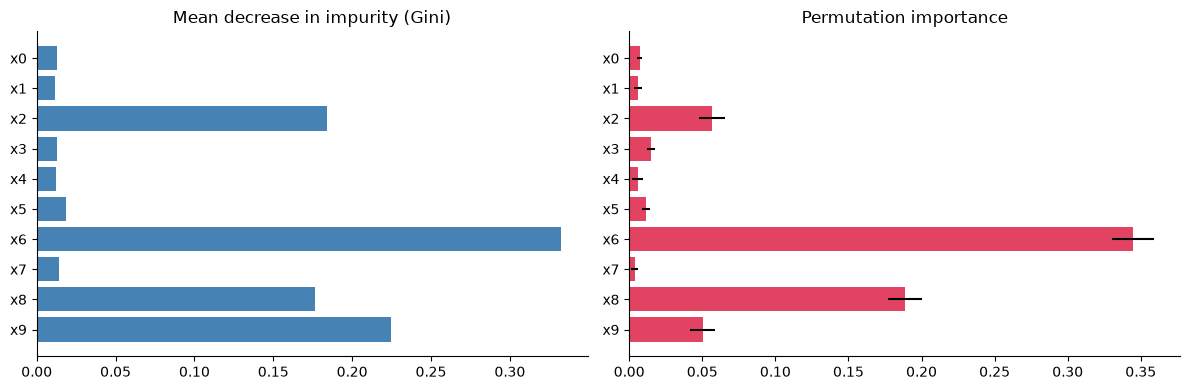

In [9]:
from sklearn.inspection import permutation_importance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mdi = m.feature_importances_
axes[0].barh(range(len(mdi)), mdi, color='steelblue')
axes[0].set_yticks(range(len(mdi))); axes[0].set_yticklabels([f'x{j}' for j in range(len(mdi))])
axes[0].set_title('Mean decrease in impurity (Gini)')
axes[0].invert_yaxis()

perm = permutation_importance(m, X, y, n_repeats=20, random_state=0)
axes[1].barh(range(len(perm.importances_mean)), perm.importances_mean,
             xerr=perm.importances_std, color='crimson', alpha=0.8)
axes[1].set_yticks(range(len(mdi))); axes[1].set_yticklabels([f'x{j}' for j in range(len(mdi))])
axes[1].set_title('Permutation importance')
axes[1].invert_yaxis()
for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 10. Tree models and the bias-variance tradeoff

Single tree: low bias, very high variance.
Bagging / RF: same bias, much less variance.
Boosting: low bias (each new tree fits the residual), low variance
(each tree is small and contributes little). Trade-off controlled by
`learning_rate` and `n_estimators`:

- Smaller η → need more trees → better fit but slower.
- **Best practice:** fix η small (0.01-0.1) and pick M by early stopping on
  a validation set.

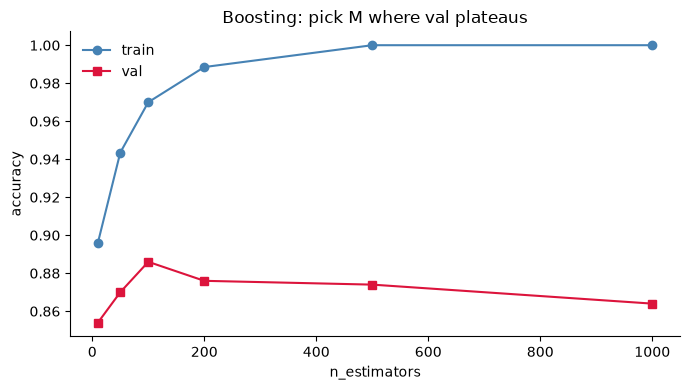

In [10]:
from sklearn.model_selection import validation_curve
param_range = [10, 50, 100, 200, 500, 1000]
tr, va = validation_curve(GradientBoostingClassifier(learning_rate=0.05, random_state=0),
                          X, y, param_name='n_estimators', param_range=param_range, cv=5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(param_range, tr.mean(axis=1), marker='o', color='steelblue', label='train')
ax.plot(param_range, va.mean(axis=1), marker='s', color='crimson',  label='val')
ax.set_xlabel('n_estimators'); ax.set_ylabel('accuracy')
ax.set_title('Boosting: pick M where val plateaus')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Summary

| Method | Variance | Bias | When to use |
|---|---|---|---|
| Single tree | high | low | interpretability |
| Bagging | medium | low | fast, decent baseline |
| Random forest | low | low | strong default |
| AdaBoost | low | low | legacy |
| Gradient boosting | low | low | strong default on tabular |

**Production rule (2024):** start with `LGBMClassifier()` or `XGBClassifier()`.
Add Random Forest for comparison. Reach for linear models only if you need
extrapolation or interpretable coefficients.

## Summary (course-facing)

| Concept | Key point |
|---|---|
| CART | top-down greedy; Gini/entropy for classification, RSS for regression |
| Pre-pruning | max_depth, min_samples_leaf |
| Bagging | variance reduction by averaging bootstrapped trees |
| Random Forest | bagging + random feature subsets at each split |
| Boosting | sequential, each tree fits the negative gradient of the loss |
| Variable importance | MDI (fast) vs permutation (slower, more reliable) |

**Next:** `10_svm_and_kernel_methods.ipynb` — the third axis of modeling:
maximum-margin classifiers and the kernel trick.